<div class="alert alert-info"> 
    
# IX. Exercise: Putting it All Together

The power of Xarray is most apparent when working with data that has three or more dimensions. We saw many examples of that in the Xarray lesson. However, in this exercise you'll work with the same 1D and 2D data that was used in the NumPy exercise and do much of the same analysis. The purpose of this is to give you more practice with file input/output, creating simpler Xarray data structures, and clearly demonstrating differences between analysis with unlabeled (NumPy) vs labeled (Xarray) array data structures.

This exercise is in a separate file from the main lesson so that you can more easily reference the content in other notebooks if you need to, by having multiple files open side-by-side in Jupyter Lab.

In this exercise you will use Xarray (as well as NumPy, Pandas, and Matplotlib) to read .txt and .nc files, create Xarray DataArrays, execute calculations, and visualize results. The data files contain the Nino3.4 Index as well as monthly precipitation anomalies at 10 different US cities. The overarching task will be to get this data into Xarray DataArrays, calculate the mean precipitation anomaly at each city during El Nina and La Nina months, and visualize your calculations.
</div>

In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

<div class="alert alert-info"> 

## 1) Intro to the El Nino Southern Oscillation (ENSO)

**The information in this section is an exact copy from the NumPy lesson. If you remember this content, feel free to skip to the next section. The content is repeated here for your convenience in case ENSO is a new concept for you or if it has been a while since you completed the NumPy lesson.**

Start by watching this short video about the El Nino Southern Oscillation climate phenomenon and how it affects precipitation and temperature in the United States.

<video controls width="560" src="https://oceanservice.noaa.gov/facts/elninolanina/otkn_721_elninolanina_lg.mp4"></video>

As you saw in the video, ENSO is a feature of Earth's natural climate variability that impacts weather globally. It has 3 phases: El Nino (warm tropical Pacific), La Nina (cool tropical Pacific), and neutral (normal tropical Pacific). Over North America, the phase of ENSO modulates the location of the jet stream and the storm systems that travel along it. This results in areas of wetter/drier and cooler/warmer weather during El Nino and La Nina conditions. Weather impacts from El Nino and La Nina are generally strongest in winter months over North America. The strongest ENSO influence on US precipitation is seen in the southern United States from southern California to Florida. 

Scientists have developed a few different *indexes* for tracking the phase and strength of ENSO over time. The ENSO index we will use in this exercise is called the Nino3.4 Index. This index is created from monthly sea surface temperature anomalies (departure from the long term mean) from a region in the tropical Pacific ocean known as the Nino3.4 region. 

For the purposes of this exercise, we will select months with El Nino and La Nina using the following criteria:
- El Nino conditions - months when the Index is greater than or equal to +1
- La Nina conditions - months when the Index is less than or equal to -1
  
The way research scientists identify El Nino and La Nina events from the Nino3.4 Index is little bit more complex. We won't get into the details here though since this exercise is focused on NumPy practice, not scientific rigor.
</div>

<div class="alert alert-info"> 

## 2) Read ENSO Data, Convert to DataArray, and Visualize

This time around we'll use Pandas and NumPy to read the data and convert to Xarray. 

Read the file at ```data/NOAA_ClimateIndex/Nino34ClimateIndex.txt``` into a Pandas DataFrame called ```enso``` and render a preview of the DataFrame to the screen. Make sure to use function parameters to skip any header and footer rows in the data file and assign nan to the missing data value of -99.99. 

**Hint:** We've already done this in the NumPy lesson.
</div>

In [2]:
# add your code here
enso = pd.read_csv(r'data/NOAA_ClimateIndex/Nino34ClimateIndex.txt',
                   header=None,
                   skiprows=1,
                   skipfooter=3,
                   na_values=-99.99,
                   delimiter=r'\s+',
                   names=np.arange(1,13),
                   engine='python')
enso

,1,2,3,4,5,6,7,8,9,10,11,12
1948,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1949,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1950,-1.99,-1.69,-1.42,-1.54,-1.75,-1.27,-1.01,-0.97,-0.98,-1.03,-1.23,-1.31
1951,-1.30,-1.04,-0.38,-0.23,-0.01,0.00,0.30,0.17,0.51,0.49,0.55,0.31
1952,0.13,-0.01,-0.11,-0.02,-0.14,-0.54,-0.76,-0.56,-0.36,-0.46,-0.78,-0.39
...,...,...,...,...,...,...,...,...,...,...,...,...
2021,-1.00,-1.00,-0.80,-0.72,-0.46,-0.28,-0.39,-0.53,-0.55,-0.94,-0.94,-1.06
2022,-0.94,-0.89,-0.97,-1.11,-1.11,-0.75,-0.69,-0.97,-1.07,-0.99,-0.90,-0.85
2023,-0.72,-0.46,-0.11,0.14,0.46,0.84,1.02,1.35,1.60,1.72,2.02,2.03
2024,1.81,1.52,1.13,0.77,0.23,0.17,0.04,-0.12,-0.26,-0.27,-0.25,-0.60


<div class="alert alert-info"> 

Overwrite the ```enso``` dataframe, dropping rows that contain nan using a Pandas dataframe function. Then, use a Pandas function to count the number of missing values remaining in the dataframe, verifying that the answer is zero. Print a preview of the resulting ```enso``` dataframe.

In [3]:
# add your code here
enso = enso.dropna(how='any')
# enso.dropna(how='any',inplace=True)

print(enso.isna().sum())#.sum())
enso

1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
dtype: int64


,1,2,3,4,5,6,7,8,9,10,11,12
1950,-1.99,-1.69,-1.42,-1.54,-1.75,-1.27,-1.01,-0.97,-0.98,-1.03,-1.23,-1.31
1951,-1.30,-1.04,-0.38,-0.23,-0.01,0.00,0.30,0.17,0.51,0.49,0.55,0.31
1952,0.13,-0.01,-0.11,-0.02,-0.14,-0.54,-0.76,-0.56,-0.36,-0.46,-0.78,-0.39
1953,0.20,0.24,0.29,0.22,0.35,0.39,0.14,0.09,0.29,0.16,0.18,0.41
1954,0.43,0.28,-0.38,-1.17,-0.81,-0.93,-1.18,-1.43,-1.60,-1.48,-1.13,-1.33
...,...,...,...,...,...,...,...,...,...,...,...,...
2020,0.60,0.37,0.48,0.36,-0.27,-0.34,-0.30,-0.59,-0.83,-1.26,-1.42,-1.15
2021,-1.00,-1.00,-0.80,-0.72,-0.46,-0.28,-0.39,-0.53,-0.55,-0.94,-0.94,-1.06
2022,-0.94,-0.89,-0.97,-1.11,-1.11,-0.75,-0.69,-0.97,-1.07,-0.99,-0.90,-0.85
2023,-0.72,-0.46,-0.11,0.14,0.46,0.84,1.02,1.35,1.60,1.72,2.02,2.03


<div class="alert alert-info"> 

Create a Pandas DatetimeIndex called ```time``` of monthly datetimes for all the years remaining in the dataframe. The day in each datetime should be the first day of the month. 


In [4]:
time = pd.date_range('1950-01','2024-12',freq='MS')
time

DatetimeIndex(['1950-01-01', '1950-02-01', '1950-03-01', '1950-04-01',
               '1950-05-01', '1950-06-01', '1950-07-01', '1950-08-01',
               '1950-09-01', '1950-10-01',
               ...
               '2024-03-01', '2024-04-01', '2024-05-01', '2024-06-01',
               '2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01',
               '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', length=900, freq='MS')

<div class="alert alert-info"> 

Convert the ```enso``` DataFrame to a 1D NumPy array called ```enso_np``` where the values of the Nino3.4 Index are sequential in time from 1950 to 2024. 

**Hint:** Reference the following sections in the NumPy lesson for the functions you will need:
- Converting between Pandas and NumPy Data Structures
- Removing and Collapsing Dimensions
</div>

In [5]:
# add your code here
enso_np = enso.to_numpy().flatten()

<div class="alert alert-info"> 

Write two assert statements to check your work. The statements should check if:
- the first 12 values of ```enso_np``` array are equal to the first row of the ```enso``` dataframe
- the length of the ```enso_np``` array is equal to the length of the ```time``` DatetimeIndex

In [6]:
assert all(enso_np[0:12]==enso.loc[1950]),'first 12 values of enso_np and enso do not match'
assert all(enso_np[0:12]==enso.iloc[0]),'first 12 values of enso_np and enso do not match' # alternative
assert len(enso_np)==len(time),'length of enso_arr and time do not match'

<div class="alert alert-info"> 

Convert the ```enso_np``` array to a 1D Xarray DataArray called ```enso_xr``` and include the following metadata/labels:
- dimension name is time
- coordinate values equal to the ```time``` DatetimeIndex
- time attributes ```{'standard_name':'time', 'long_name':'time, in monthly increments`}```
- variable attributes ```{'standard_name':'nino34', 'units':'degrees_C'}```
</div>

In [7]:
# add your code here

enso_xr = xr.DataArray(enso_np, coords = {'time':('time',time)})

enso_xr.time.attrs = {'standard_name':'time', 'long_name':'time, in monthly increments'}
enso_xr.attrs = {'standard_name':'nino34', 'units':'degrees_C'}

enso_xr

<xarray.DataArray (time: 900)> Size: 7kB
array([-1.99, -1.69, -1.42, -1.54, -1.75, -1.27, -1.01, -0.97, -0.98,
       -1.03, -1.23, -1.31, -1.3 , -1.04, -0.38, -0.23, -0.01,  0.  ,
        0.3 ,  0.17,  0.51,  0.49,  0.55,  0.31,  0.13, -0.01, -0.11,
       -0.02, -0.14, -0.54, -0.76, -0.56, -0.36, -0.46, -0.78, -0.39,
        0.2 ,  0.24,  0.29,  0.22,  0.35,  0.39,  0.14,  0.09,  0.29,
        0.16,  0.18,  0.41,  0.43,  0.28, -0.38, -1.17, -0.81, -0.93,
       -1.18, -1.43, -1.6 , -1.48, -1.13, -1.33, -0.93, -0.95, -1.06,
       -1.22, -1.28, -1.18, -1.15, -1.35, -1.43, -2.31, -2.45, -2.03,
       -1.2 , -0.99, -0.83, -0.97, -0.8 , -0.92, -1.06, -1.17, -0.98,
       -0.97, -1.14, -0.89, -0.51, -0.22,  0.18,  0.41,  0.62,  0.63,
        0.87,  0.84,  0.72,  0.7 ,  0.92,  1.3 ,  1.78,  1.49,  0.98,
        0.46,  0.38,  0.26,  0.03, -0.01, -0.32, -0.27,  0.05,  0.02,
        0.53,  0.43,  0.19,  0.06, -0.23, -0.35, -0.86, -0.77, -0.8 ,
       -0.48, -0.66, -0.42, -0.28, -0.46, -0.3 , -0.33, -0.25, -0.49,
       -0.41, -0.15, -0.28, -0.49, -0.45, -0.38, -0.31, -0.19, -0.35,
       -0.46, -0.18, -0.06, -0.41, -0.67, -0.94, -1.01, -0.63, -0.63,
       -0.59, -0.57, -0.48, -0.69, -0.89, -0.65, -0.53, -0.53, -0.78,
       -0.75, -0.95, -0.93, -0.78, -0.53, -0.1 , -0.03, -0.3 , -0.11,
        0.49,  0.62,  0.68,  0.64,  0.77,  1.02,  0.79,  0.38, -0.26,
       -0.87, -1.12, -1.14, -0.96, -1.26, -1.4 , -1.35, -1.44, -1.37,
...
        1.52,  1.25,  0.9 ,  0.38, -0.22, -0.69, -1.07, -1.39, -1.6 ,
       -1.69, -1.64, -1.6 , -1.54, -1.11, -0.93, -0.77, -0.52, -0.38,
       -0.43, -0.65, -0.8 , -1.05, -1.19, -1.06, -0.87, -0.67, -0.61,
       -0.5 , -0.32,  0.02,  0.25,  0.47,  0.38,  0.26,  0.16, -0.25,
       -0.53, -0.52, -0.25, -0.25, -0.4 , -0.42, -0.39, -0.38, -0.18,
       -0.2 , -0.14, -0.17, -0.49, -0.62, -0.28,  0.08,  0.32,  0.23,
       -0.06, -0.03,  0.29,  0.44,  0.75,  0.71,  0.51,  0.42,  0.47,
        0.7 ,  0.92,  1.18,  1.46,  1.93,  2.21,  2.36,  2.72,  2.66,
        2.57,  2.26,  1.62,  0.91,  0.3 , -0.03, -0.48, -0.58, -0.58,
       -0.74, -0.76, -0.5 , -0.43, -0.08,  0.03,  0.22,  0.37,  0.34,
        0.25, -0.16, -0.43, -0.56, -0.97, -0.98, -0.98, -0.78, -0.8 ,
       -0.51, -0.2 ,  0.04,  0.12,  0.09,  0.47,  0.9 ,  0.9 ,  0.89,
        0.65,  0.71,  0.81,  0.62,  0.55,  0.45,  0.35,  0.04,  0.03,
        0.48,  0.52,  0.52,  0.6 ,  0.37,  0.48,  0.36, -0.27, -0.34,
       -0.3 , -0.59, -0.83, -1.26, -1.42, -1.15, -1.  , -1.  , -0.8 ,
       -0.72, -0.46, -0.28, -0.39, -0.53, -0.55, -0.94, -0.94, -1.06,
       -0.94, -0.89, -0.97, -1.11, -1.11, -0.75, -0.69, -0.97, -1.07,
       -0.99, -0.9 , -0.85, -0.72, -0.46, -0.11,  0.14,  0.46,  0.84,
        1.02,  1.35,  1.6 ,  1.72,  2.02,  2.03,  1.81,  1.52,  1.13,
        0.77,  0.23,  0.17,  0.04, -0.12, -0.26, -0.27, -0.25, -0.6 ])
Coordinates:
  * time     (time) datetime64[ns] 7kB 1950-01-01 1950-02-01 ... 2024-12-01
Attributes:
    standard_name:  nino34
    units:          degrees_C

<div class="alert alert-info"> 

Just for extra practice, count how many total NaNs there are in ```enso_xr``` using NumPy or Xarray functions. 

**Hint:** We covered the NumPy function to count nans but we didn't cover the similar Xarray function for this: ```.isnull()```. See if you can get the same result using both methods.

</div>

In [8]:
# add your code here
print(np.isnan(enso_xr).sum())
print(enso_xr.isnull().sum())

<xarray.DataArray ()> Size: 8B
array(0)
<xarray.DataArray ()> Size: 8B
array(0)


<div class="alert alert-info"> 

Finally, use Xarray ```.plot()``` to plot the Nino3.4 Index timeseries (```enso_xr```). Include the parameter ```figsize=(10,2)``` and add a grey dashed reference line at y=0.

</div>

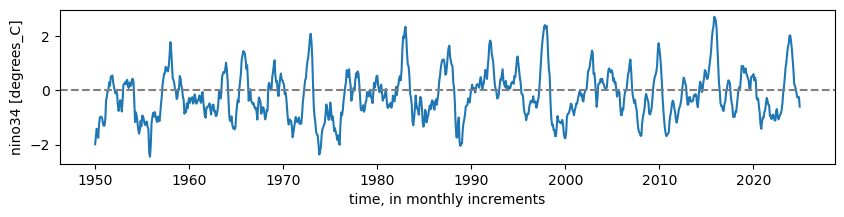

In [9]:
# add your code here
enso_xr.plot(figsize=(10,2))
plt.axhline(0,color='grey',ls='dashed')
plt.show()

**Interpreting the figure above:** The further away from zero the index is (in either direction), the stronger the ENSO event. The more positive the index is, the stronger the EL Nino phenomenon. The more negative the index is, the stronger the La Nina phenomenon. Neutral conditions occur when the index is closer to zero. 

<div class="alert alert-info"> 

## 3) Read Netcdf file to Xarray Dataset and Practice Manipulating Xarray Data Structures

The monthly precipitation anomalies from the nclimgrid data for the same 10 cities we worked with in the NumPy exercise are provided in the netcdf file ```data/nclimgrid/pr_anom_nclimgrid_monthly_10cities.nc```. 

Read the file into an Xarray Dataset called ```ds``` and print the ```ds``` metadata to the screen.
</div>

In [19]:
# add your code here

ds = xr.open_dataset('data/nclimgrid/pr_anom_nclimgrid_monthly_10cities.nc')
ds

<xarray.Dataset> Size: 45kB
Dimensions:   (time: 925, location: 10)
Coordinates:
  * time      (time) datetime64[ns] 7kB 1948-01-01 1948-02-01 ... 2025-01-01
  * location  (location) <U12 480B 'San Diego' 'Tucson' ... 'Orlando'
    lat       (location) float32 40B ...
    lon       (location) float32 40B ...
Data variables:
    pr_anom   (location, time) float32 37kB ...

<div class="alert alert-info"> 

Write an assert statement to check if the times in ```ds``` match the times in ```enso_xr```.  **FIX THIS HERE AND LOOK FOR ANY OTHER JANKY ASSERT STATEMENTS IN OTHER NOTEBOOKS**
</div>

In [21]:
# assert all(ds.time.data==enso_xr.time.data),'times in ds and enso_x do not match'

xr.testing.assert_equal(ds.time,enso_xr.time)


AssertionError: Left and right DataArray objects are not equal
Differing dimensions:
    (time: 925) != (time: 900)
Differing values:
L
    array(['1948-01-01T00:00:00.000000000', '1948-02-01T00:00:00.000000000',
           '1948-03-01T00:00:00.000000000', ..., '2024-11-01T00:00:00.000000000',
           '2024-12-01T00:00:00.000000000', '2025-01-01T00:00:00.000000000'],
          shape=(925,), dtype='datetime64[ns]')
R
    array(['1950-01-01T00:00:00.000000000', '1950-02-01T00:00:00.000000000',
           '1950-03-01T00:00:00.000000000', ..., '2024-10-01T00:00:00.000000000',
           '2024-11-01T00:00:00.000000000', '2024-12-01T00:00:00.000000000'],
          shape=(900,), dtype='datetime64[ns]')
Differing coordinates:
L * time     (time) datetime64[ns] 7kB 1948-01-01 1948-02-01 ... 2025-01-01
R * time     (time) datetime64[ns] 7kB 1950-01-01 1950-02-01 ... 2024-12-01

<div class="alert alert-info"> 

Overwrite ```ds``` so that the times match enso_xr. You can accomplish this either by slicing in time or using advanced indexing. Afterward, paste a copy of the ```xr.testing.assert_equals()``` from above and run it to check again for a match between all times.
</div>

In [22]:
# add your code here
ds = ds.sel(time=enso_xr.time)
ds = ds.sel(time=slice(enso_xr.time[0],enso_xr.time[-1]))
xr.testing.assert_equal(ds.time,enso_xr.time)

<div class="alert alert-info"> 

Save the data variable pr_anom in the Dataset ```ds``` to a new Xarray DataArray object called ```pr```.
</div>

In [ ]:
# add your code here
pr = ds.pr_anom
pr

<div class="alert alert-info"> 

Using the ```pr``` DataArray, programmatically show the longitude of the Tucson location.
</div>

In [ ]:
pr.lon.sel(location='Tucson').data

<div class="alert alert-info"> 
    
Count how many NaNs there are in the ```pr``` array. This can be accomplished with Xarray or NumPy functions, the choice is yours.
</div>

In [ ]:
# add your code here
pr.isnull().sum()
np.isnan(pr).sum()

<div class="alert alert-info"> 
    
Convert ```pr``` from units of mm to units of inches (this is an example of broadcasting). 
</div>

In [ ]:
# add your code here
pr = pr/25.4
pr

<div class="alert alert-info"> 

Find the most positive and most negative value of ```pr``` at each location.

In [ ]:
# add your code here

pr.max('time')

In [ ]:
# add your code here
pr.min('time')

<div class="alert alert-info"> 

## 4) Use Advanced Indexing to Find Mean Precipitation Anomalies during El Nino and La Nina Months

First, using a comparison operator, create True/False masks to identify El Nino and La Nina months in the Nino3.4 Index.
- Create a variable called ```nino_mask``` where ```enso_xr``` meets or exceeds a value of +1.0
- Create a variable called ```nina_mask``` where ```enso_xr``` meets or exceeds a value of -1.0

Your ```nino_mask``` and ```nina_mask``` objects should be Xarray DataArrays.


In [ ]:
# ds = xr.open_dataset('data/nclimgrid/pr_anom_nclimgrid_monthly_10cities.nc')
# ds

In [ ]:
# assert all(enso_xr.time == ds.time), 'times in enso_xr and ds objects do not match'

In [ ]:
# add your code here
nino_mask = (enso_xr>=1)
nina_mask = (enso_xr<=-1)
print(type(nino_inds))
nino_inds

<div class="alert alert-info"> 

How many El Nino months are there in ```nino_mask``` and how many La Nina months in ```nina_mask```?

In [ ]:
# add your code here
nino_mask.sum(),nina_mask.sum()

<div class="alert alert-info"> 
    
Use advanced indexing to select the time values in ```nino_mask``` that correspond to the El Nino months. In other words, display the datetimes where the ```nino_mask``` is True.

In [ ]:
# add your code here
nino_mask.sel(time=nino_mask).time

<div class="alert alert-info"> 

Chain additional functions onto the line of code you just wrote to answer the question: How many times does each month of the year occur in the 82 El Nino months?

**Hint:** the [list of methods you can use with ```.groupby()``` from the Xarray API reference](https://docs.xarray.dev/en/stable/generated/xarray.core.groupby.DataArrayGroupBy.html#xarray.core.groupby.DataArrayGroupBy) may be helpful 

In [ ]:
# add your code here
nino_mask.sel(time=nino_mask).time.groupby('time.month').count()

<div class="alert alert-info"> 

Using advanced indexing, select only the values of ```pr``` that correspond to El Nino months (using ```nino_mask```). You don't need to save this as a separate variable. It's just practice for the next step.

In [ ]:
# add your code here
pr.sel(time=nino_mask)

In [ ]:
# # ninoDJF = 
# # ninoDJF
# ninoDJF = xr.where( (nino_inds[nino_inds].time.dt.month >=11) | (nino_inds[nino_inds].time.dt.month <=2),1,np.nan).dropna('time')
# ninoDJF

In [ ]:
# nino_mean = ds.pr_anom.sel(time=ninoDJF.time).mean('time')
# # nina_mean = ds.pr_anom.sel(time=nina_inds).mean('time')
# # nino_mean.shape,nina_mean.shape
# nino_mean

In [ ]:
# print(max(nino_mean).location.data)

<div class="alert alert-info"> 

Use advanced indexing to find the mean of ```pr``` for each city during:
-  El Nino months (```nino_mask```), save to a variable called ```nino_mean```
-  La Nina months (```nina_mask```), save to a variable called ```nina_mean```

Verify that each resulting array you created (```nino_mean``` and ```nina_mean```) is a 1D array of length 10.
</div>

In [ ]:
# add your code here
nino_mean = pr.sel(time=nino_mask).mean('time')
nina_mean = pr.sel(time=nina_mask).mean('time')
print(nino_mean.shape,nina_mean.shape)
nino_mean

<div class="alert alert-info"> 

## 5) Elementwise Math, Sorting, and Visualization

Subtract the mean pr anomaly during La Nina months from the mean pr anomaly during El Nino months for each city (elementwise math) and save the result to a variable called ```diff```.
</div>

In [ ]:
# add your code here
diff = nino_mean - nina_mean
diff

<div class="alert alert-info"> 

Answer the following questions programmatically by accessing the location coordinate values in ```nino_mean```, ```nina_mean```, and ```diff```:
- Which city has the largest mean precip anomaly during El Nino months?
- Which city has the largest mean precip anomaly during La Nina months?
- Which city has the largest difference between mean precip anomalies in El Nino vs La Nina months?

</div>

In [ ]:
# add your code here
print(max(nino_mean).location.data)
print(max(nina_mean).location.data)
print(max(diff).location.data)

In [ ]:
# add your code here
# # fig = plt.figure(figsize=(8,2))
# diff.plot(figsize=(8,2),marker='o',lw=0)
# plt.xticks(rotation=300,ha='left')
# plt.ylabel('Precipitation (inches)')
# plt.title('nino minus nina mean monthly precip anomaly difference')
# plt.show()


# add your code here
fig = plt.figure(figsize=(8,2))
diff.plot(marker='o',lw=0)
plt.xticks(rotation=300,ha='left')
plt.ylabel('Precipitation (inches)')
plt.title('nino minus nina mean monthly precip anomaly difference')
plt.show()

<div class="alert alert-info"> 

Use matplotlib.pyplot's [```plt.plot()```](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html) to plot your ```diff``` results in a figure with the following:
- x axis shows the city names,
- y axis shows the ```diff``` values,
- lineweight is zero (no line) and marker is a shape of your choice,
- include a y axis label with units,
- include a plot title,
- rotate your x axis tick labels (city names) with ```plt.xticks(rotation=300,ha='left')```

**Hint: These instructions are the same as in the NumPy exercise. Copy the plot you created in that exercise and modify it to plot the Xarray DataArray ```diff```.**

</div>

In [ ]:
# add your code here
fig = plt.figure(figsize=(8,2))
diff.plot(marker='o',lw=0)
plt.xticks(rotation=300,ha='left')
plt.ylabel('Precipitation (inches)')
plt.title('nino minus nina mean monthly precip anomaly difference')
plt.show()

<div class="alert alert-info"> 

Sort the ```diff``` values in ascending order and save the result to a new variable called ```sorted_diff```. 

**Hint:** With [Xarray's ```.sortby()``` function](https://docs.xarray.dev/en/latest/generated/xarray.DataArray.sortby.html), data and coordinate values are sorted all at once in one line of code. 
</div>

In [ ]:
# add your code here to sort
sorted_diff = diff.sortby(diff)
sorted_diff

<div class="alert alert-info"> 

Now, recreate the plot above, but make it a bar chart using matplotlib.pyplot's [```plt.bar()```](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html) with the city names and ```sorted_diff``` values appearing in ascending order from left to right. 

In [ ]:
# add your code here to plot
fig = plt.figure(figsize=(8,3))
plt.bar(sorted_diff.location.data,sorted_diff)
plt.xticks(rotation=300,ha='left')
plt.ylabel('Precipitation (inches)')
plt.title('nino minus nina mean monthly precip anomaly difference')
plt.show()